In [4]:
import pandas as pd

baseline = pd.read_csv("../runs/cv_summary_baseline.csv")
reweigh = pd.read_csv("../runs/cv_summary_reweighing.csv")
expgrad = pd.read_csv("../runs/cv_summary_expgrad.csv")
threshold = pd.read_csv("../runs/cv_summary_threshold.csv")

def select_core_metrics(df, mitigation_label):
    return pd.DataFrame({
        "Model": df["model"],
        "Mitigation": mitigation_label,
        "Accuracy": df["accuracy_mean"],
        "AUC": df["auc_mean"],
        "DP": df["dp_diff_mean"],
        "DI": df["di_ratio_mean"],
        "EO": df["eo_diff_mean"],
    })

table = pd.concat([
    select_core_metrics(baseline, "baseline"),
    select_core_metrics(reweigh, "reweighing"),
    select_core_metrics(expgrad[expgrad["mitigation"] == "expgrad_dp"], "expgrad_dp"),
    select_core_metrics(expgrad[expgrad["mitigation"] == "expgrad_eo"], "expgrad_eo"),
    select_core_metrics(threshold, "threshold_eo"),
], ignore_index=True)

table


,Model,Mitigation,Accuracy,AUC,DP,DI,EO
0,gb,baseline,0.860135,0.814650,0.022006,0.625308,0.096459
1,logreg,baseline,0.879054,0.834744,0.035993,0.715402,0.167136
2,rf,baseline,0.857432,0.814007,0.008367,0.647126,0.058519
3,gb,reweighing,0.863514,0.815229,0.018648,0.674621,0.088975
4,logreg,reweighing,0.879054,0.834155,0.035993,0.715402,0.167136
5,rf,reweighing,0.856081,0.815212,0.006951,0.699517,0.043679
6,logreg,expgrad_dp,0.879730,0.693907,0.037069,0.708009,0.167136
7,logreg,expgrad_eo,0.879730,0.695544,0.041101,0.678226,0.202129
8,logreg,threshold_eo,0.872973,0.759108,0.050560,0.701513,0.214379


In [5]:
table.to_csv("../runs/tradeoff_table.csv", index=False)


In [7]:
baseline_row = table[table["Mitigation"] == "baseline"].iloc[0]
delta = table.copy()

for col in ["Accuracy", "AUC", "DP", "DI", "EO"]:
    delta[f"Δ_{col}"] = delta[col] - baseline_row[col]

delta

delta.to_csv("../runs/tradeoff_deltas.csv", index=False)



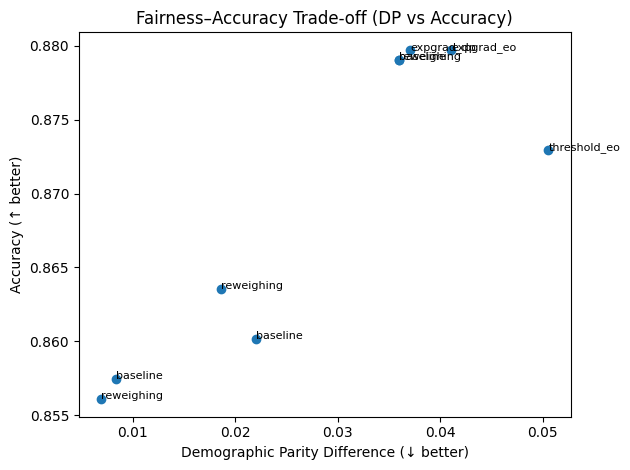

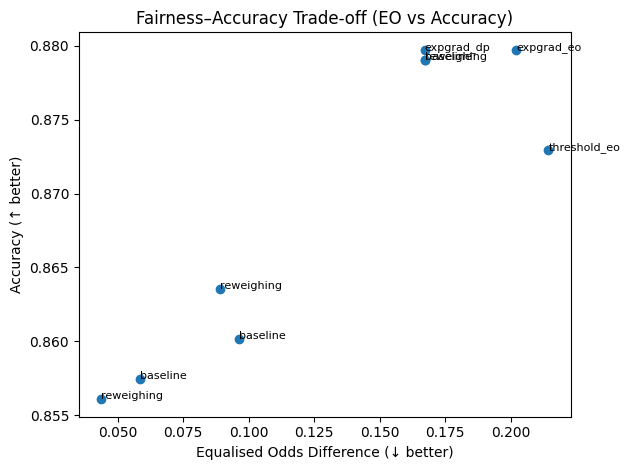

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(table["DP"], table["Accuracy"])

for _, row in table.iterrows():
    plt.text(row["DP"], row["Accuracy"], row["Mitigation"], fontsize=8)

plt.xlabel("Demographic Parity Difference (↓ better)")
plt.ylabel("Accuracy (↑ better)")
plt.title("Fairness–Accuracy Trade-off (DP vs Accuracy)")
plt.tight_layout()
plt.savefig("../runs/fairness_vs_accuracy_dp.png")
plt.show()

plt.figure()
plt.scatter(table["EO"], table["Accuracy"])

for _, row in table.iterrows():
    plt.text(row["EO"], row["Accuracy"], row["Mitigation"], fontsize=8)

plt.xlabel("Equalised Odds Difference (↓ better)")
plt.ylabel("Accuracy (↑ better)")
plt.title("Fairness–Accuracy Trade-off (EO vs Accuracy)")
plt.tight_layout()
plt.savefig("../runs/fairness_vs_accuracy_eo.png")
plt.show()
